In [134]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import r2_score, mean_squared_error

import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler

import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import xgboost as xgb

import catboost as cb

from sklearn.ensemble import StackingRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression

In [135]:
df = pd.read_csv('/kaggle/input/linear-regression-dataset/kaggle.csv',sep=";",encoding= 'unicode_escape')

In [136]:
df

,age,shoe_size,price(£),sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f
5,8,31,7,m
6,9,30,6,f
7,9,30,7,m
8,10,29,8,f
9,11,32,5,m


In [137]:
df.rename(columns={'price(£)': 'price'}, inplace=True)

In [138]:
df

,age,shoe_size,price,sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f
5,8,31,7,m
6,9,30,6,f
7,9,30,7,m
8,10,29,8,f
9,11,32,5,m


In [139]:
df.shape

(15, 4)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        15 non-null     int64 
 1   shoe_size  15 non-null     int64 
 2   price      15 non-null     int64 
 3   sex        15 non-null     object
dtypes: int64(3), object(1)
memory usage: 608.0+ bytes


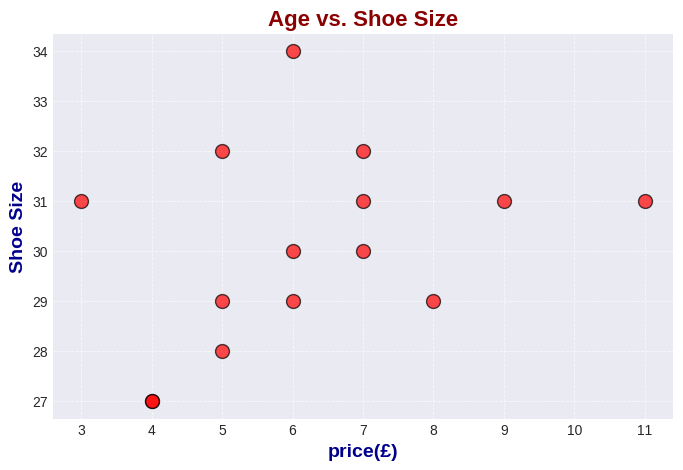

In [141]:
# Set a modern style
plt.style.use('seaborn-v0_8-darkgrid')

# Create the scatter plot with enhancements
plt.figure(figsize=(8, 5))
plt.scatter(df.price, df.shoe_size, color="red", edgecolors="black", alpha=0.7, s=100, marker="o")

# Add labels with styling
plt.xlabel("price(£)", fontsize=14, fontweight="bold", color="darkblue")
plt.ylabel("Shoe Size", fontsize=14, fontweight="bold", color="darkblue")
plt.title("Age vs. Shoe Size", fontsize=16, fontweight="bold", color="darkred")

# Add grid and customize the look
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

# Show the plot
plt.show()

In [142]:
# Convert categorical 'sex' into numerical values
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])

In [143]:
df

,age,shoe_size,price,sex
0,3,27,4,1
1,4,27,4,1
2,5,28,5,1
3,6,29,5,0
4,7,29,6,0
5,8,31,7,1
6,9,30,6,0
7,9,30,7,1
8,10,29,8,0
9,11,32,5,1


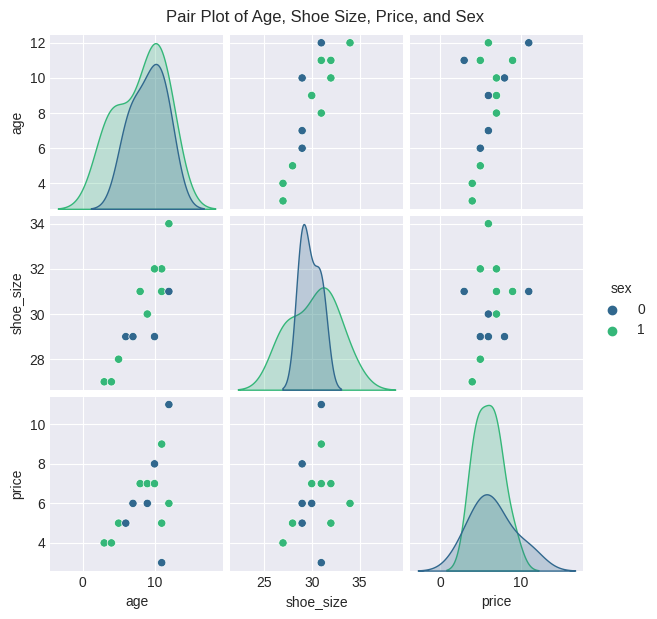

In [144]:
# Create a pair plot
sns.pairplot(df, hue="sex", palette="viridis", height=2)
plt.suptitle("Pair Plot of Age, Shoe Size, Price, and Sex", y=1.02)
plt.show()

In [145]:
# Define features and target
X = df[['age', 'shoe_size', 'price', 'sex']]
y = df['price']  # You can choose any column as target, assuming price is your target variable here

In [146]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [147]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [148]:
# Initialize the model (Random Forest)
model = RandomForestClassifier()

In [149]:
# Fit the model
model.fit(X_train, y_train)

# Predict the results
y_pred = model.predict(X_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 40.00%


In [150]:
# Initialize the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

In [151]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [152]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [153]:
# Get the best model
best_model = grid_search.best_estimator_
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [154]:
# Predict and evaluate
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred.round())  # Rounding the predictions for classification tasks

print(f"Best Model Accuracy: {accuracy * 100:.2f}%")

Best Model Accuracy: 80.00%


In [155]:
# Polynomial Regression (Degree 2 & 3)
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    # Model Evaluation
    print(f"🔹 Polynomial Regression (Degree {degree}):")
    print("MSE:", mean_squared_error(y_test, y_pred_poly))
    print("R² Score:", r2_score(y_test, y_pred_poly))
    print("-" * 40)

🔹 Polynomial Regression (Degree 2):
MSE: 0.856566715585077
R² Score: 0.7106193528428795
----------------------------------------
🔹 Polynomial Regression (Degree 3):
MSE: 0.862602089695247
R² Score: 0.7085803751029571
----------------------------------------


In [156]:
# Feature engineering: create new features
df['age_to_shoe_size_ratio'] = df['age'] / df['shoe_size']
df['age_and_price_interaction'] = df['age'] * df['price']

In [157]:
df

,age,shoe_size,price,sex,age_to_shoe_size_ratio,age_and_price_interaction
0,3,27,4,1,0.111111,12
1,4,27,4,1,0.148148,16
2,5,28,5,1,0.178571,25
3,6,29,5,0,0.206897,30
4,7,29,6,0,0.241379,42
5,8,31,7,1,0.258065,56
6,9,30,6,0,0.300000,54
7,9,30,7,1,0.300000,63
8,10,29,8,0,0.344828,80
9,11,32,5,1,0.343750,55


In [158]:
# Define features and target
X1 = df[['age', 'shoe_size', 'price', 'sex', 'age_to_shoe_size_ratio', 'age_and_price_interaction']]
y1 = df['price']  # You can adjust the target column

In [159]:
# Split the data into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

In [160]:
# 🔹 Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train1, y_train1)
y_pred_linear = linear_model.predict(X_test1)

In [161]:
# Polynomial Regression (Degree 2 & 3)
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train1)
    X_test_poly = poly.transform(X_test1)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train1)
    y_pred_poly = poly_model.predict(X_test_poly)

    # Model Evaluation
    print(f"🔹 Polynomial Regression (Degree {degree}):")
    print("MSE:", mean_squared_error(y_test1, y_pred_poly))
    print("R² Score:", r2_score(y_test1, y_pred_poly))
    print("-" * 40)

🔹 Polynomial Regression (Degree 2):
MSE: 0.01273089991180259
R² Score: 0.9956990203000667
----------------------------------------
🔹 Polynomial Regression (Degree 3):
MSE: 0.2993297335443229
R² Score: 0.8988750900188098
----------------------------------------


In [162]:
# 🔹 Linear Regression Evaluation
print("🔹 Linear Regression:")
print("MSE:", mean_squared_error(y_test1, y_pred_linear))
print("R² Score:", r2_score(y_test1, y_pred_linear))

🔹 Linear Regression:
MSE: 7.888609052210118e-31
R² Score: 1.0
